In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Save model
import joblib

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_dataset.csv to customer_churn_dataset (1).csv


In [ ]:
df = pd.read_csv("/content/customer_churn_dataset.csv")
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [ ]:
df.shape

(20000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


In [ ]:
df.describe

<bound method NDFrame.describe of        customer_id  tenure  monthly_charges  total_charges        contract  \
0                1      52            54.20        2818.40  Month-to-month   
1                2      15            35.28         529.20  Month-to-month   
2                3      72            78.24        5633.28  Month-to-month   
3                4      61            80.24        4894.64        One year   
4                5      21            39.38         826.98  Month-to-month   
...            ...     ...              ...            ...             ...   
19995        19996      36            69.51        2502.36        Two year   
19996        19997      10            59.88         598.80  Month-to-month   
19997        19998       6            42.96         257.76  Month-to-month   
19998        19999       7           102.85         719.95  Month-to-month   
19999        20000      31            44.84        1390.04        Two year   

      payment_method internet_service tech_support online_security  \
0             Credit              DSL           No             Yes   
1              Debit              DSL           No              No   
2              Debit              DSL           No              No   
3               Cash            Fiber          Yes             Yes   
4                UPI            Fiber           No              No   
...              ...              ...          ...             ...   
19995           Cash              DSL           No             Yes   
19996            UPI            Fiber          Yes              No   
19997         Credit            Fiber           No              No   
19998          Debit              DSL          Yes              No   
19999         Credit            Fiber          Yes              No   

       support_calls churn  
0                  1    No  
1                  2    No  
2                  0    No  
3                  0    No  
4                  4   Yes  
...              ...   ...  
19995              0   Yes  
19996              1    No  
19997              2    No  
19998              2    No  
19999              1   Yes  

[20000 rows x 11 columns]>

In [ ]:
df.isnull().sum()

,0
customer_id,0
tenure,0
monthly_charges,0
total_charges,0
contract,0
payment_method,0
internet_service,2013
tech_support,0
online_security,0
support_calls,0


In [ ]:
df["churn"].value_counts()

,count
churn,
No,13157
Yes,6843


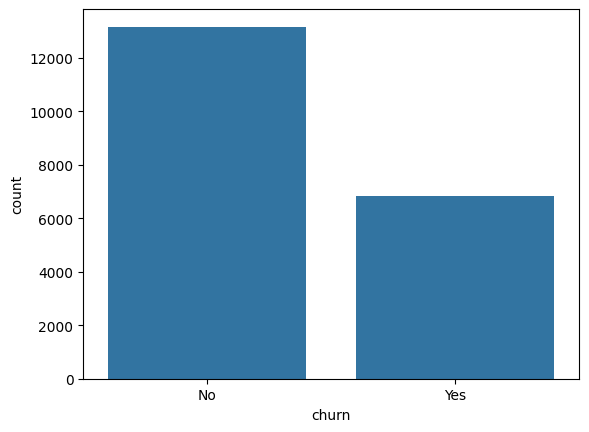

In [ ]:
sns.countplot(x="churn", data=df)
plt.show()

In [ ]:
df = df.drop("customer_id", axis=1)

In [ ]:
df.head()

,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [ ]:
df["churn"] = df["churn"].map({
    "Yes":1,
    "No":0
})

In [ ]:
df.head()

,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,0
1,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,0
2,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,0
3,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,0
4,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,1


In [ ]:
X = df.drop("churn", axis=1)

categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical Features")

print(categorical_cols)

print()

print("Numerical Features")

print(numerical_cols)

Categorical Features
Index(['contract', 'payment_method', 'internet_service', 'tech_support',
       'online_security'],
      dtype='object')

Numerical Features
Index(['tenure', 'monthly_charges', 'total_charges', 'support_calls'], dtype='object')


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,tenure,monthly_charges,total_charges,support_calls,contract_One year,contract_Two year,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,tech_support_Yes,online_security_Yes
0,52,54.20,2818.40,1,False,False,True,False,False,False,False,True
1,15,35.28,529.20,2,False,False,False,True,False,False,False,False
2,72,78.24,5633.28,0,False,False,False,True,False,False,False,False
3,61,80.24,4894.64,0,True,False,False,False,False,True,True,True
4,21,39.38,826.98,4,False,False,False,False,True,True,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [ ]:
from sklearn.model_selection import train_test_split

y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (16000, 12)
Testing Data: (4000, 12)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [ ]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.77575
Precision: 0.7458333333333333
Recall   : 0.5230094959824689
F1 Score : 0.6148561614426793


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.79      0.91      0.84      2631
           1       0.75      0.52      0.61      1369

    accuracy                           0.78      4000
   macro avg       0.77      0.72      0.73      4000
weighted avg       0.77      0.78      0.76      4000



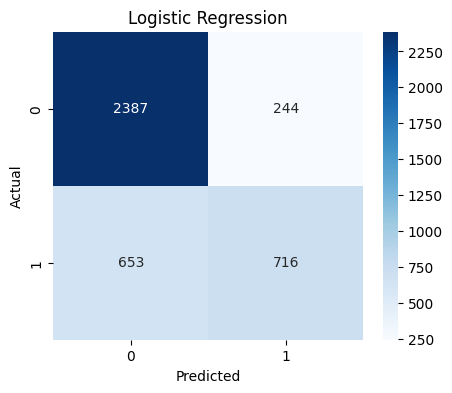

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.83625
Precision: 0.8374291115311909
Recall   : 0.6471877282688093
F1 Score : 0.7301194890811702


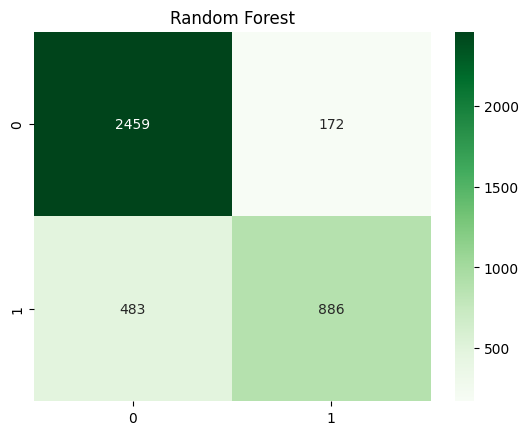

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Greens")

plt.title("Random Forest")
plt.show()

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))

Accuracy : 0.845
Precision: 0.8576886341929322
Recall   : 0.6559532505478451
F1 Score : 0.7433774834437086


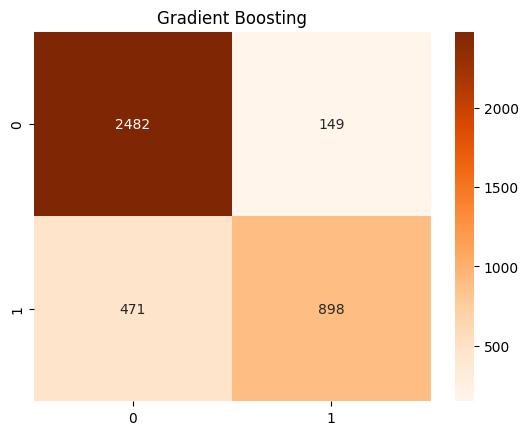

In [ ]:
cm = confusion_matrix(y_test, gb_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Oranges")

plt.title("Gradient Boosting")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.77575,0.745833,0.523009,0.614856
1,Random Forest,0.83625,0.837429,0.647188,0.730119
2,Gradient Boosting,0.84500,0.857689,0.655953,0.743377


In [ ]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,0.84500,0.857689,0.655953,0.743377
1,Random Forest,0.83625,0.837429,0.647188,0.730119
0,Logistic Regression,0.77575,0.745833,0.523009,0.614856


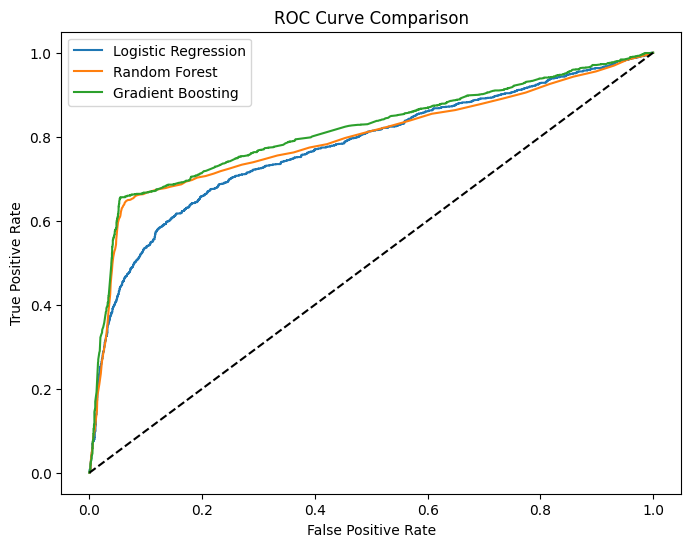

In [ ]:
lr_prob = lr.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
gb_prob = gb.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label="Logistic Regression")

plt.plot(fpr_rf, tpr_rf,
         label="Random Forest")

plt.plot(fpr_gb, tpr_gb,
         label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(lr_cv)
print("Average Accuracy:", lr_cv.mean())

[0.792   0.77425 0.77575 0.7715  0.78375]
Average Accuracy: 0.77945


In [ ]:
gb_cv = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(gb_cv)
print("Average Accuracy:", gb_cv.mean())

[0.85575 0.84575 0.836   0.84025 0.848  ]
Average Accuracy: 0.8451500000000001


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
best_rf = grid.best_estimator_

prediction = best_rf.predict(X_test)

print(classification_report(y_test, prediction))

print("Accuracy:",
      accuracy_score(y_test, prediction))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2631
           1       0.87      0.66      0.75      1369

    accuracy                           0.85      4000
   macro avg       0.85      0.80      0.82      4000
weighted avg       0.85      0.85      0.84      4000

Accuracy: 0.84725


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,monthly_charges,0.265780
3,support_calls,0.147225
2,total_charges,0.130453
0,tenure,0.124256
10,tech_support_Yes,0.123136
4,contract_One year,0.094869
5,contract_Two year,0.068715
9,internet_service_Fiber,0.012059
11,online_security_Yes,0.011120
6,payment_method_Credit,0.007680


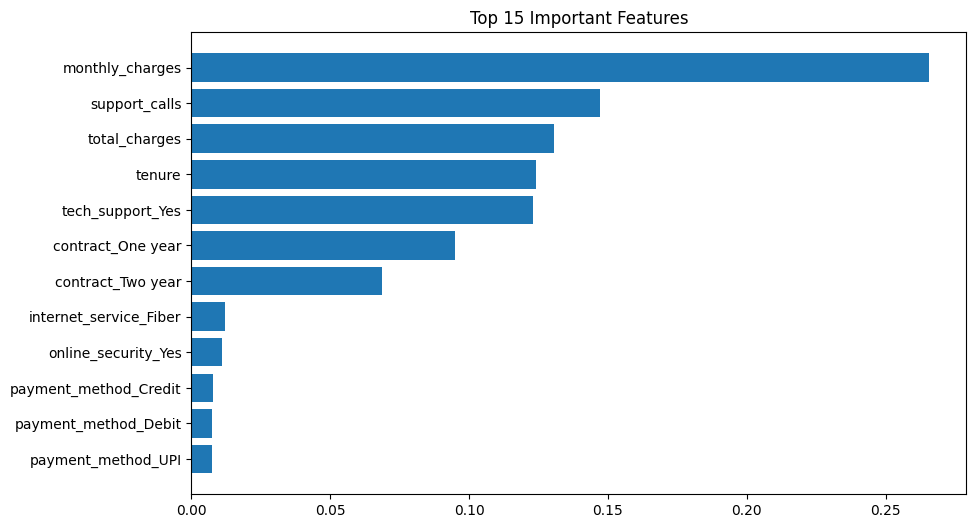

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
import joblib

joblib.dump(best_rf, "best_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']